In [37]:
%run encode.ipynb

         asin                                              title  price_eur  \
0  B0G71BJS8S  Microsoft Surface Laptop, 13.8" | Snapdragon X...    1056.07   
1  B0DYDVFVTJ  Microsoft Surface Laptop, 13" | Snapdragon X P...     735.54   
2  B0F8L98RLY  HP Laptop | 15,6" FHD Display | Intel N100 | 4...     219.00   
3  B0H28V9JGR  Laptop 15,6 Zoll 8GB RAM 256GB SSD Notebook Fu...     249.19   
4  B0DJBQ8Y7K  HP Chromebook x360 Laptop (14" HD Touchscreen,...     219.00   

   rating  reviews  ram_gb  storage_gb  screen_size_inch  touchscreen  gaming  \
0     4.8     15.0    16.0       512.0              13.8        False   False   
1     4.3     74.0    16.0       256.0              13.0        False   False   
2     4.1    170.0     4.0       128.0              15.6        False    True   
3     4.2      8.0     8.0       256.0              15.6        False    True   
4     4.2    181.0     4.0       128.0              14.0         True    True   

   ... resolution_2560x1600  resolutio

In [41]:
# X و y
x = df_encoded.drop(
    columns=[
        "price_eur",
        "asin",
        "title",
        "product_url",
        "search_page"
    ],
    errors="ignore"
)

y = df_encoded["price_eur"]

# Correlation با price
corr = x.corrwith(y).abs().sort_values(ascending=False)

# 20 ویژگی برتر
selected_features_corr = corr.head(20).index

# X نهایی
x_corr = x[selected_features_corr]

print("Selected features:")
print(list(selected_features_corr))

print("\nMissing features:")
print(set(selected_features_corr) - set(x.columns))

Selected features:
['storage_gb', 'ram_gb', 'resolution_2560x1600', 'gpu_NVIDIA GeForce RTX 5090', 'resolution_1920x1080', 'cpu_Intel Core Ultra 9', 'gpu_NVIDIA GeForce RTX 5080', 'gpu_Intel UHD Graphics', 'cpu_Intel Core Ultra 9 275HX', 'resolution_3840x2400', 'brand_MSI', 'gpu_NVIDIA GeForce RTX 5070', 'gpu_NVIDIA GeForce RTX 5070Ti', 'cpu_AMD Ryzen AI 9HX', 'screen_size_inch', 'brand_Amazon Renewed', 'gpu_NVIDIA GeForce RTX 4080', 'os_Windows 11 Home', 'cpu_Intel Core i9-13900HX', 'resolution_2400x1600']

Missing features:
set()


c:\Users\BiG\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\BiG\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [44]:
corr = x.corrwith(y)

corr = corr.abs().sort_values(ascending=False)

print(corr.head(20))

storage_gb                       0.666885
ram_gb                           0.657143
resolution_2560x1600             0.474678
gpu_NVIDIA GeForce RTX 5090      0.435808
resolution_1920x1080             0.427071
cpu_Intel Core Ultra 9           0.405862
gpu_NVIDIA GeForce RTX 5080      0.362933
gpu_Intel UHD Graphics           0.342160
cpu_Intel Core Ultra 9 275HX     0.308390
resolution_3840x2400             0.304287
brand_MSI                        0.274536
gpu_NVIDIA GeForce RTX 5070      0.265455
gpu_NVIDIA GeForce RTX 5070Ti    0.249694
cpu_AMD Ryzen AI 9HX             0.249694
screen_size_inch                 0.219775
brand_Amazon Renewed             0.216078
gpu_NVIDIA GeForce RTX 4080      0.210074
os_Windows 11 Home               0.208135
cpu_Intel Core i9-13900HX        0.196803
resolution_2400x1600             0.179568
dtype: float64


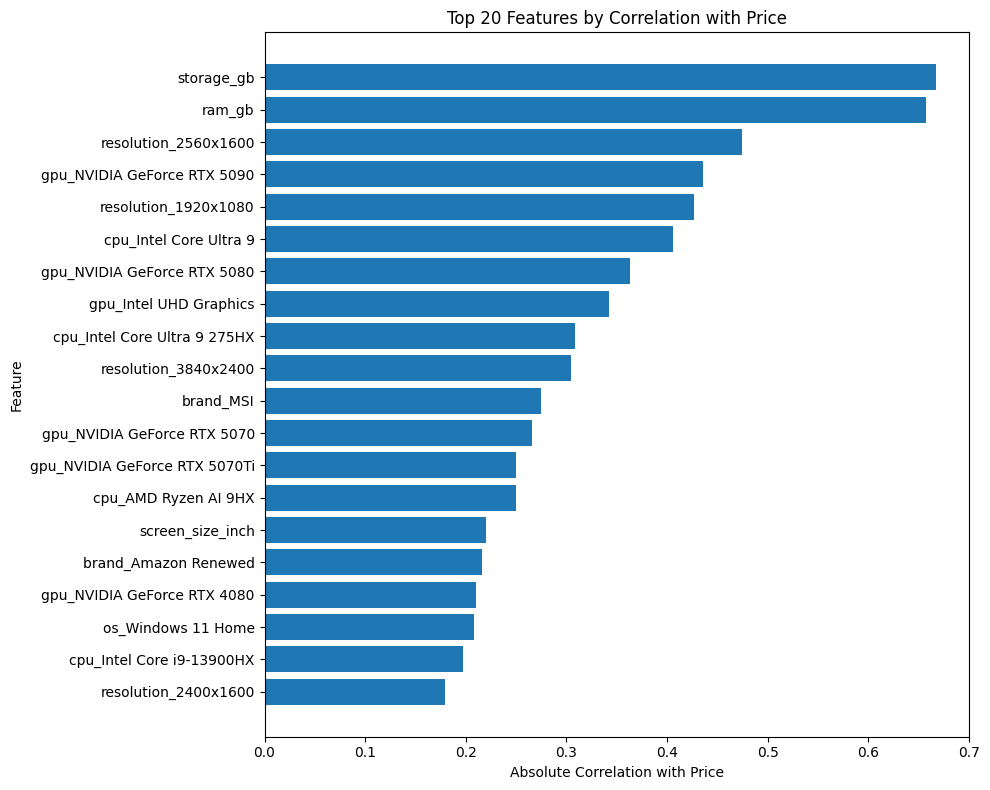

In [45]:
import matplotlib.pyplot as plt

top20 = corr.head(20).sort_values()

plt.figure(figsize=(10, 8))
plt.barh(top20.index, top20.values)

plt.xlabel("Absolute Correlation with Price")
plt.ylabel("Feature")
plt.title("Top 20 Features by Correlation with Price")

plt.tight_layout()
plt.show()

c:\Users\BiG\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\BiG\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


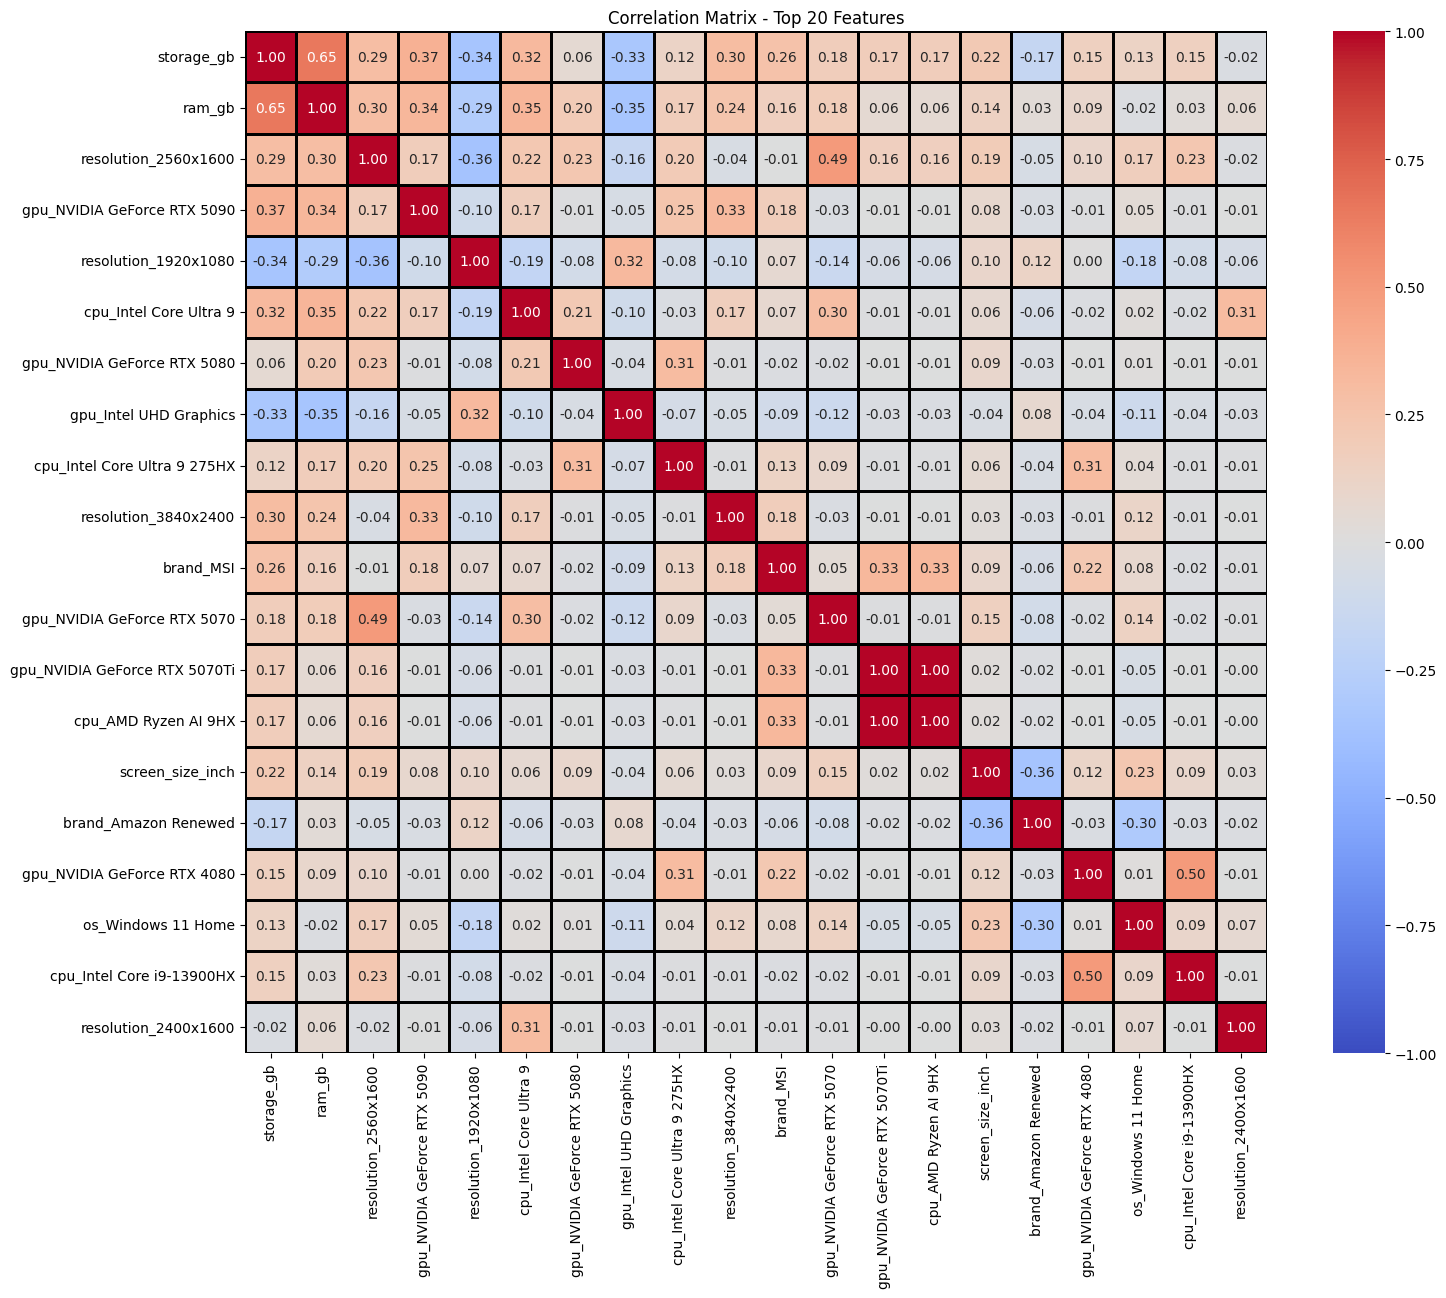

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# حذف ستون‌های غیرقابل استفاده
x = df_encoded.drop(
    columns=[
        "price_eur",
        "asin",
        "title",
        "product_url",
        "search_page"
    ],
    errors="ignore"
)

# پیدا کردن 20 ویژگی برتر از نظر ارتباط با قیمت
corr_with_price = x.corrwith(
    df_encoded["price_eur"]
).abs().sort_values(ascending=False)

top20_features = corr_with_price.head(20).index

# ساخت ماتریس correlation
corr_matrix = x[top20_features].corr()

# رسم Heatmap
plt.figure(figsize=(16, 13))

sns.heatmap(
    corr_matrix,
    annot=True,        # نمایش عدد داخل مربع
    fmt=".2f",         # دو رقم اعشار
    cmap="coolwarm",   # رنگ‌بندی
    vmin=-1,
    vmax=1,
    linewidths=1,      # خط بین مربع‌ها
    linecolor="black", # رنگ خطوط
    square=True
)

plt.title("Correlation Matrix - Top 20 Features")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [47]:
print(x_corr.shape)
print(x_corr.columns)

(277, 20)
Index(['storage_gb', 'ram_gb', 'resolution_2560x1600',
       'gpu_NVIDIA GeForce RTX 5090', 'resolution_1920x1080',
       'cpu_Intel Core Ultra 9', 'gpu_NVIDIA GeForce RTX 5080',
       'gpu_Intel UHD Graphics', 'cpu_Intel Core Ultra 9 275HX',
       'resolution_3840x2400', 'brand_MSI', 'gpu_NVIDIA GeForce RTX 5070',
       'gpu_NVIDIA GeForce RTX 5070Ti', 'cpu_AMD Ryzen AI 9HX',
       'screen_size_inch', 'brand_Amazon Renewed',
       'gpu_NVIDIA GeForce RTX 4080', 'os_Windows 11 Home',
       'cpu_Intel Core i9-13900HX', 'resolution_2400x1600'],
      dtype='object')


In [48]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

x_corr = df_encoded[selected_features_corr]
y = df_encoded["price_eur"]

X_train, X_test, y_train, y_test = train_test_split(
    x_corr,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Correlation Feature Selection")
print("MAE:", mae)
print("R²:", r2)

Correlation Feature Selection
MAE: 367.2179760027263
R²: 0.48099754577990383
